# 🩺 DiaCompanion — Phân đoạn tổn thương DR trên TJDR
## U-Net Đa lớp · EfficientNet-B4 · Google Colab T4

---

**Bộ dữ liệu:** TJDR (Mao et al., 2023 — arXiv:2312.15389)  
**Model:** U-Net với encoder EfficientNet-B4 (pretrained ImageNet)  
**5 lớp:** `0=Nền` · `1=EX (Exudates)` · `2=HE (Hemorrhages)` · `3=MA (Microaneurysms)` · `4=SE (Soft Exudates)`

### 📋 Quy trình chạy
| Cell | Nội dung | Kiểm tra |
|------|----------|----------|
| 0 | Kiểm tra GPU | Thấy `Tesla T4` ✅ |
| 1 | Cài thư viện & import | Không có lỗi import ✅ |
| 2 | Mount Drive + đường dẫn | Thấy số file > 0 ✅ |
| 3 | **Quét nhãn tự động** | Thấy đủ 5 giá trị + GRAY2CLS ✅ |
| 4 | Verify phân bố pixel | EX/HE/MA/SE đều > 0% ✅ |
| 5 | Ghép cặp ảnh–mask + split | Số cặp = 448 (hoặc gần đó) ✅ |
| 6 | Dataset + Augmentation | Batch shape `[4, 3, 768, 768]` ✅ |
| 7 | Model EfficientNet-B4 | ~19M tham số ✅ |
| 8 | Loss + Optimizer | Không lỗi ✅ |
| 9 | **Train loop** | mDice tăng dần qua epoch ✅ |
| 10 | Đánh giá test set | Dice/IoU per-lesion ✅ |
| 11 | Visualize | Ảnh màu: đỏ=EX lục=HE lam=MA vàng=SE ✅ |
| 12 | Lưu model về Drive | `✅ Model đã lưu vào Drive` ✅ |

> ⚠️ **Lưu ý y khoa:** Đây là công cụ nghiên cứu/capstone, không thay thế chẩn đoán của bác sĩ nhãn khoa.

---
## Cell 0 — Kiểm tra GPU
> **Làm trước tiên:** `Runtime → Change runtime type → T4 GPU`  
> Nếu thấy `CPU only` → đổi runtime rồi **Restart & Run All**

In [1]:
!nvidia-smi -L
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️  Không có GPU — vào Runtime > Change runtime type > T4")

GPU 0: Tesla T4 (UUID: GPU-d476394d-ff9f-7702-7c90-79ade03ba98c)
CUDA available: True
GPU: Tesla T4


---
## Cell 1 — Cài thư viện & Import
> Cài `segmentation-models-pytorch==0.3.4` và `albumentations==1.4.0`.  
> Nếu bị lỗi version conflict → restart runtime sau khi cài xong rồi chạy lại từ đây.

In [2]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.0

import torch, cv2, numpy as np, os, glob, random
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss
import matplotlib.pyplot as plt
import shutil

print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ SMP         : {smp.__version__}")
print(f"✅ Albumentations : {A.__version__}")
print(f"✅ OpenCV      : {cv2.__version__}")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.9 MB/s eta 0:00:00
✅ PyTorch     : 2.11.0+cu128
✅ SMP         : 0.3.4
✅ Albumentations : 1.4.0
✅ OpenCV      : 4.13.0


---
## Cell 2 — Mount Google Drive & Đường dẫn dataset
> **Cấu trúc thư mục TJDR trong Drive:**
> ```
> MyDrive/TJDR/
>   train/
>     image/        ← ảnh fundus .jpg/.png
>     annotation/   ← mask grayscale .png
> ```
> Nếu cấu trúc khác → sửa `IMG_DIR` và `MASK_DIR` cho đúng.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── SỬA hai đường dẫn này nếu cần ──────────────────────────
DATA_ROOT = '/content/drive/MyDrive/TJDR'
IMG_DIR   = os.path.join(DATA_ROOT, 'train/image')
MASK_DIR  = os.path.join(DATA_ROOT, 'train/annotation')
# ────────────────────────────────────────────────────────────

img_files  = sorted(glob.glob(os.path.join(IMG_DIR,  '*')))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, '*')))

print(f"📁 IMG_DIR  : {IMG_DIR}")
print(f"📁 MASK_DIR : {MASK_DIR}")
print(f"🖼  Số ảnh  : {len(img_files)}")
print(f"🎭 Số mask  : {len(mask_files)}")

assert len(img_files)  > 0, "❌ Không tìm thấy ảnh  — kiểm tra IMG_DIR"
assert len(mask_files) > 0, "❌ Không tìm thấy mask — kiểm tra MASK_DIR"
print("\n✅ Đường dẫn hợp lệ")

Mounted at /content/drive
📁 IMG_DIR  : /content/drive/MyDrive/TJDR/train/image
📁 MASK_DIR : /content/drive/MyDrive/TJDR/train/annotation
🖼  Số ảnh  : 448
🎭 Số mask  : 448

✅ Đường dẫn hợp lệ


---
## Cell 3 — 🔍 Quét nhãn tự động (FIX CHÍNH)
> **Đây là cell quan trọng nhất** — fix bug EX bị mất.  
> Thay vì hardcode `{0:0, 14:1, 38:2, 75:3, 113:4}` (sai với nhiều phiên bản TJDR),  
> ta quét **100 mask trước**, nếu chưa đủ 5 giá trị thì **quét toàn bộ** dataset.
>
> **Output mong đợi:** `GRAY2CLS tự động: {0: 0, X: 1, Y: 2, Z: 3, W: 4}`  
> trong đó X/Y/Z/W là các giá trị grayscale thực tế của EX/HE/MA/SE.

In [4]:
def scan_label_values(mask_paths, n=None):
    """Quét n mask (None = toàn bộ) để thu thập mọi giá trị grayscale duy nhất."""
    vals = set()
    sample = mask_paths if n is None else mask_paths[:n]
    for mp in sample:
        raw = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
        if raw is None:
            continue
        if raw.ndim == 3:
            raw = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
        vals |= set(np.unique(raw).tolist())
    return sorted(vals)

# ── Bước 1: quét nhanh 100 mask ──────────────────────────────
print("🔍 Quét 100 mask đầu...")
raw_vals = scan_label_values(mask_files, n=100)
print(f"   Giá trị tìm thấy: {raw_vals}  ({len(raw_vals)} giá trị)")

# ── Bước 2: nếu chưa đủ 5 → quét full ───────────────────────
if len(raw_vals) < 5:
    print(f"\n⚠️  Chưa đủ 5 lớp trong 100 mask đầu. Quét toàn bộ {len(mask_files)} mask...")
    raw_vals = scan_label_values(mask_files, n=None)
    print(f"   Giá trị sau quét full: {raw_vals}  ({len(raw_vals)} giá trị)")

assert len(raw_vals) == 5, (
    f"❌ Cần đúng 5 giá trị nhãn (nền + 4 tổn thương), thấy {len(raw_vals)}: {raw_vals}\n"
    "   → Kiểm tra lại MASK_DIR hoặc cấu trúc folder dataset."
)

# ── Bước 3: build GRAY2CLS tự động ───────────────────────────
# Giả định: giá trị nhỏ nhất = nền (0), còn lại theo thứ tự tăng dần = EX HE MA SE
GRAY2CLS = {v: i for i, v in enumerate(raw_vals)}

print("\n" + "═"*50)
print(f"  GRAY2CLS tự động : {GRAY2CLS}")
print("─"*50)
print(f"  Nền (BG) ← gray={raw_vals[0]}")
print(f"  EX       ← gray={raw_vals[1]}")
print(f"  HE       ← gray={raw_vals[2]}")
print(f"  MA       ← gray={raw_vals[3]}")
print(f"  SE       ← gray={raw_vals[4]}")
print("═"*50)
print("✅ Build GRAY2CLS thành công")

🔍 Quét 100 mask đầu...
   Giá trị tìm thấy: [0, 15, 38, 75, 113]  (5 giá trị)

══════════════════════════════════════════════════
  GRAY2CLS tự động : {0: 0, 15: 1, 38: 2, 75: 3, 113: 4}
──────────────────────────────────────────────────
  Nền (BG) ← gray=0
  EX       ← gray=15
  HE       ← gray=38
  MA       ← gray=75
  SE       ← gray=113
══════════════════════════════════════════════════
✅ Build GRAY2CLS thành công


---
## Cell 4 — ✅ Verify phân bố pixel (Quan trọng)
> Kiểm tra xem sau khi remap, tất cả 4 lớp tổn thương đều có pixel không.  
> Nếu EX = 0% → GRAY2CLS sai thứ tự → báo lỗi ngay, không train vô ích.  
> Quét **50 mask ngẫu nhiên** để đại diện toàn dataset.

In [5]:
def load_mask(mp):
    """Đọc mask gốc và remap về 0–4 theo GRAY2CLS."""
    raw = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
    if raw is None:
        raise FileNotFoundError(f"Không đọc được: {mp}")
    if raw.ndim == 3:
        raw = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    out = np.zeros(raw.shape, np.uint8)
    for g, c in GRAY2CLS.items():
        out[raw == g] = c
    return out

# Đếm pixel mỗi class trên 50 mask ngẫu nhiên
_sample = random.sample(mask_files, min(50, len(mask_files)))
_counts = {i: 0 for i in range(5)}
for mp in _sample:
    m = load_mask(mp)
    for c in range(5):
        _counts[c] += int((m == c).sum())

_total  = sum(_counts.values())
_labels = {0:'BG', 1:'EX', 2:'HE', 3:'MA', 4:'SE'}
_colors = {0:'⬛', 1:'🟥', 2:'🟩', 3:'🟦', 4:'🟨'}

print(f"📊 Phân bố pixel trên {len(_sample)} mask ngẫu nhiên")
print("═"*55)
for c, cnt in _counts.items():
    pct = 100 * cnt / _total
    bar = '█' * max(1, int(40 * cnt / _total)) if cnt > 0 else ''
    print(f"  {_colors[c]} Class {c} ({_labels[c]:3s}): {cnt:>11,} px  {pct:6.3f}%  {bar}")
print("═"*55)

assert _counts[1] > 0, "❌ EX (class 1) = 0 pixel! GRAY2CLS có thể sai thứ tự."
assert _counts[2] > 0, "❌ HE (class 2) = 0 pixel!"
assert _counts[3] > 0, "❌ MA (class 3) = 0 pixel!"
assert _counts[4] > 0, "❌ SE (class 4) = 0 pixel!"
print("\n✅ Tất cả 4 lớp tổn thương đều có pixel — mapping hợp lệ, sẵn sàng train!")

📊 Phân bố pixel trên 50 mask ngẫu nhiên
═══════════════════════════════════════════════════════
  ⬛ Class 0 (BG ): 496,838,805 px  99.655%  ███████████████████████████████████████
  🟥 Class 1 (EX ):     424,472 px   0.085%  █
  🟩 Class 2 (HE ):     533,740 px   0.107%  █
  🟦 Class 3 (MA ):     745,102 px   0.149%  █
  🟨 Class 4 (SE ):      18,521 px   0.004%  █
═══════════════════════════════════════════════════════

✅ Tất cả 4 lớp tổn thương đều có pixel — mapping hợp lệ, sẵn sàng train!


---
## Cell 5 — Ghép cặp ảnh–mask & Train/Val/Test Split
> Ghép theo **stem name** (tên file không có extension).  
> Split tỉ lệ **70/15/15** với `seed=42` để tái lập.  
> In 5 cặp đầu để xác nhận tên file khớp nhau.

In [6]:
def stem(p):
    return os.path.splitext(os.path.basename(p))[0]

mask_by_stem = {stem(m): m for m in mask_files}
pairs = [(ip, mask_by_stem[stem(ip)]) for ip in img_files if stem(ip) in mask_by_stem]

print(f"🔗 Số cặp ghép được: {len(pairs)} / {len(img_files)} ảnh")
assert len(pairs) > 0, "❌ Không ghép được ảnh-mask — kiểm tra quy tắc đặt tên file"

# Debug: in 5 cặp đầu
print("\n5 cặp ảnh–mask đầu tiên:")
print(f"  {'Ảnh':<30} {'Mask':<30} {'Classes'}")
print("  " + "─"*75)
for ip, mp in pairs[:5]:
    m = load_mask(mp)
    classes = np.unique(m).tolist()
    print(f"  {os.path.basename(ip):<30} {os.path.basename(mp):<30} {classes}")

# Split 70/15/15
SEED = 42
random.seed(SEED)
random.shuffle(pairs)

n      = len(pairs)
n_tr   = int(0.70 * n)
n_va   = int(0.15 * n)
train_pairs = pairs[:n_tr]
val_pairs   = pairs[n_tr:n_tr+n_va]
test_pairs  = pairs[n_tr+n_va:]

print(f"\n📦 Split (seed={SEED}):")
print(f"   Train : {len(train_pairs):>4} ảnh")
print(f"   Val   : {len(val_pairs):>4} ảnh")
print(f"   Test  : {len(test_pairs):>4} ảnh")

# Lưu danh sách test để tái lập
with open('test_files.txt', 'w') as f:
    for ip, _ in test_pairs:
        f.write(os.path.basename(ip) + '\n')
print("\n✅ Đã lưu test_files.txt (dùng để tái lập kết quả)")

🔗 Số cặp ghép được: 448 / 448 ảnh

5 cặp ảnh–mask đầu tiên:
  Ảnh                            Mask                           Classes
  ───────────────────────────────────────────────────────────────────────────
  TJDR_train_001.png             TJDR_train_001.png             [0, 1]
  TJDR_train_002.png             TJDR_train_002.png             [0, 2, 3]
  TJDR_train_003.png             TJDR_train_003.png             [0, 1, 3, 4]
  TJDR_train_004.png             TJDR_train_004.png             [0, 1, 4]
  TJDR_train_005.png             TJDR_train_005.png             [0, 1, 2]

📦 Split (seed=42):
   Train :  313 ảnh
   Val   :   67 ảnh
   Test  :   68 ảnh

✅ Đã lưu test_files.txt (dùng để tái lập kết quả)


---
## Cell 6 — Dataset & Augmentation
> **Kích thước:** 768×768 (giữ detail tổn thương nhỏ như MA).  
> **Train augment:** flip, rotate, elastic, grid distortion, CLAHE, brightness/contrast.  
> **Quan trọng:** mask dùng `INTER_NEAREST` (implicit qua Albumentations) — không normalize mask!

In [7]:
SIZE        = 768
NUM_CLASSES = 5
BATCH       = 4
MEAN        = (0.485, 0.456, 0.406)
STD         = (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.3),
    A.CLAHE(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

class TJDRDataset(Dataset):
    def __init__(self, pairs, tf):
        self.pairs, self.tf = pairs, tf

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        a   = self.tf(image=img, mask=load_mask(mp))
        return a['image'], a['mask'].long()

train_dl = DataLoader(TJDRDataset(train_pairs, train_tf), batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(TJDRDataset(val_pairs,   val_tf),   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(TJDRDataset(test_pairs,  val_tf),   batch_size=1,     shuffle=False)

# Sanity check batch đầu tiên
xb, yb = next(iter(train_dl))
unique_classes = torch.unique(yb).tolist()
print(f"🧪 Batch check:")
print(f"   Ảnh shape : {list(xb.shape)}  (B, C, H, W)")
print(f"   Mask shape : {list(yb.shape)}  (B, H, W)")
print(f"   Classes trong batch: {unique_classes}")

if 1 in unique_classes:
    print("✅ EX (class 1) xuất hiện trong batch đầu — mapping OK!")
else:
    print("⚠️  EX chưa xuất hiện trong batch này — bình thường nếu EX hiếm, tiếp tục train")

🧪 Batch check:
   Ảnh shape : [4, 3, 768, 768]  (B, C, H, W)
   Mask shape : [4, 768, 768]  (B, H, W)
   Classes trong batch: [0, 1, 2, 3]
✅ EX (class 1) xuất hiện trong batch đầu — mapping OK!


---
## Cell 7 — Model: EfficientNet-B4 U-Net
> Encoder **EfficientNet-B4** pretrained ImageNet → fine-tune cho segmentation.  
> Output: 5 channel logit map (1 per class).  
> Tổng tham số dự kiến: **~19M**.

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥  Device: {device}")

model = smp.Unet(
    encoder_name        = "efficientnet-b4",
    encoder_weights     = "imagenet",
    in_channels         = 3,
    classes             = NUM_CLASSES,
    decoder_use_batchnorm = True,
    decoder_attention_type = None
).to(device)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"🤖 Model: EfficientNet-B4 U-Net")
print(f"   Tham số: {n_params:.1f}M")
print(f"   Output classes: {NUM_CLASSES}")
print("✅ Model sẵn sàng")

🖥  Device: cuda
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth


100%|██████████| 74.4M/74.4M [00:01<00:00, 75.0MB/s]


🤖 Model: EfficientNet-B4 U-Net
   Tham số: 20.2M
   Output classes: 5
✅ Model sẵn sàng


---
## Cell 8 — Loss, Optimizer & Scheduler
> **Vấn đề:** tổn thương nhỏ (MA đặc biệt nhỏ), nền chiếm >99% pixel → mất cân bằng nặng.  
> **Giải pháp:** kết hợp `DiceLoss + FocalLoss` (Focal tập trung vào pixel khó).  
> Scheduler: `CosineAnnealingLR` với T_max=100 epochs.

In [9]:
dice_loss  = DiceLoss(mode='multiclass')
focal_loss = FocalLoss(mode='multiclass', alpha=0.25, gamma=2.0)

def criterion(logits, y):
    return dice_loss(logits, y) + focal_loss(logits, y)

opt       = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)
scaler    = torch.amp.GradScaler("cuda")

print("⚙️  Cấu hình training:")
print(f"   Loss      : DiceLoss + FocalLoss(alpha=0.25, gamma=2.0)")
print(f"   Optimizer : AdamW  (lr=1e-4, weight_decay=1e-4)")
print(f"   Scheduler : CosineAnnealingLR (T_max=100)")
print(f"   Mixed precision: {'✅ AMP enabled' if torch.cuda.is_available() else '❌ CPU (no AMP)'}")
print("✅ Sẵn sàng train")

⚙️  Cấu hình training:
   Loss      : DiceLoss + FocalLoss(alpha=0.25, gamma=2.0)
   Optimizer : AdamW  (lr=1e-4, weight_decay=1e-4)
   Scheduler : CosineAnnealingLR (T_max=100)
   Mixed precision: ✅ AMP enabled
✅ Sẵn sàng train


---
## Cell 9 — 🏋️ Train Loop
> **EarlyStopping:** dừng nếu val mDice không cải thiện sau **15 epoch**.  
> **Checkpoint:** lưu model tốt nhất (theo val mDice) vào `tjdr_unet_best.pth`.  
> Dự kiến train **~40–60 epoch** trước khi early stop trên T4.
>
> **Metric cần theo dõi:** mDice tăng dần. Nếu sau 20 epoch mDice < 0.1 → có vấn đề.

In [10]:
LESION = {1:'EX', 2:'HE', 3:'MA', 4:'SE'}

@torch.no_grad()
def evaluate(dl):
    model.eval()
    inter = {c: 0 for c in LESION}
    union = {c: 0 for c in LESION}
    tp    = {c: 0 for c in LESION}
    fp    = {c: 0 for c in LESION}
    fn    = {c: 0 for c in LESION}
    for x, y in dl:
        x = x.to(device); y = y.to(device)
        pred = model(x).argmax(1)
        for c in LESION:
            p = (pred == c); t = (y == c)
            inter[c] += (p & t).sum().item()
            union[c] += (p | t).sum().item()
            tp[c]    += (p & t).sum().item()
            fp[c]    += (p & ~t).sum().item()
            fn[c]    += (~p & t).sum().item()
    rows = {}
    for c in LESION:
        denom = 2*tp[c] + fp[c] + fn[c]
        dice  = 2*tp[c] / denom     if denom > 0     else float('nan')
        iou   = inter[c] / union[c] if union[c] > 0  else float('nan')
        rows[LESION[c]] = (dice, iou)
    return rows

def fmt(rows):
    return "  ".join([f"{k}: Dice={v[0]:.3f} IoU={v[1]:.3f}" for k, v in rows.items()])

# ── Train loop ───────────────────────────────────────────────
best = -1; patience = 15; wait = 0; EPOCHS = 100
print(f"🚀 Bắt đầu train — tối đa {EPOCHS} epoch, early stop sau {patience} epoch không cải thiện")
print("═" * 90)

for ep in range(1, EPOCHS+1):
    model.train(); run = 0
    for x, y in train_dl:
        x = x.to(device); y = y.to(device)
        opt.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(x)
            loss   = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run += loss.item()
    scheduler.step()

    rows  = evaluate(val_dl)
    mdice = np.nanmean([v[0] for v in rows.values()])
    flag  = " ⭐" if mdice > best else ""
    print(f"Epoch {ep:03d} | loss {run/len(train_dl):.4f} | mDice {mdice:.3f}{flag}")
    print(f"         {fmt(rows)}")

    if mdice > best:
        best = mdice; wait = 0
        torch.save(model.state_dict(), 'tjdr_unet_best.pth')
    else:
        wait += 1
        if wait >= patience:
            print(f"\n🛑 Early stopping tại epoch {ep} (best mDice={best:.3f})")
            break

print("═" * 90)
print(f"✅ Train xong — Best val mDice = {best:.3f}")

🚀 Bắt đầu train — tối đa 100 epoch, early stop sau 15 epoch không cải thiện
══════════════════════════════════════════════════════════════════════════════════════════
Epoch 001 | loss 1.5181 | mDice 0.001 ⭐
         EX: Dice=0.001 IoU=0.000  HE: Dice=0.003 IoU=0.001  MA: Dice=0.000 IoU=0.000  SE: Dice=0.000 IoU=0.000
Epoch 002 | loss 1.0584 | mDice 0.000
         EX: Dice=0.000 IoU=0.000  HE: Dice=0.001 IoU=0.001  MA: Dice=0.000 IoU=0.000  SE: Dice=0.000 IoU=0.000
Epoch 003 | loss 0.9400 | mDice 0.000
         EX: Dice=0.000 IoU=0.000  HE: Dice=0.000 IoU=0.000  MA: Dice=0.000 IoU=0.000  SE: Dice=0.000 IoU=0.000
Epoch 004 | loss 0.8481 | mDice 0.000
         EX: Dice=0.000 IoU=0.000  HE: Dice=0.000 IoU=0.000  MA: Dice=0.000 IoU=0.000  SE: Dice=0.000 IoU=0.000
Epoch 005 | loss 0.8230 | mDice 0.000
         EX: Dice=0.000 IoU=0.000  HE: Dice=0.000 IoU=0.000  MA: Dice=0.000 IoU=0.000  SE: Dice=0.000 IoU=0.000
Epoch 006 | loss 0.7902 | mDice 0.000
         EX: Dice=0.000 IoU=0.000  HE: Dice

---
## Cell 10 — 📊 Đánh giá trên tập Test
> Load lại model tốt nhất → đánh giá trên tập test chưa dùng lúc train.  
> **Mốc tham chiếu TJDR/IDRiD (state-of-the-art):** IoU ~0.66, F1 ~0.79.

In [11]:
model.load_state_dict(torch.load('tjdr_unet_best.pth', map_location=device))
rows = evaluate(test_dl)

print("📊 KẾT QUẢ TEST (per-lesion)")
print("═" * 55)
print(f"  {'Tổn thương':<10} {'Dice':>8} {'IoU':>8}")
print("  " + "─"*30)
dices, ious = [], []
for name, (dice, iou) in rows.items():
    print(f"  {name:<10} {dice:>8.3f} {iou:>8.3f}")
    if not np.isnan(dice): dices.append(dice)
    if not np.isnan(iou):  ious.append(iou)
print("  " + "─"*30)
print(f"  {'Mean':<10} {np.mean(dices):>8.3f} {np.mean(ious):>8.3f}")
print("═" * 55)
print("\n📌 Tham chiếu SOTA (TJDR/IDRiD): IoU ~0.66 | F1 ~0.79")

📊 KẾT QUẢ TEST (per-lesion)
═══════════════════════════════════════════════════════
  Tổn thương     Dice      IoU
  ──────────────────────────────
  EX            0.607    0.436
  HE            0.585    0.413
  MA            0.645    0.476
  SE            0.217    0.122
  ──────────────────────────────
  Mean          0.514    0.362
═══════════════════════════════════════════════════════

📌 Tham chiếu SOTA (TJDR/IDRiD): IoU ~0.66 | F1 ~0.79


---
## Cell 11 — 🖼 Visualize dự đoán
> Hiển thị 3 mẫu từ tập test: ảnh gốc | ground truth | dự đoán.  
> Màu sắc: 🔴 đỏ = EX · 🟢 lục = HE · 🔵 lam = MA · 🟡 vàng = SE

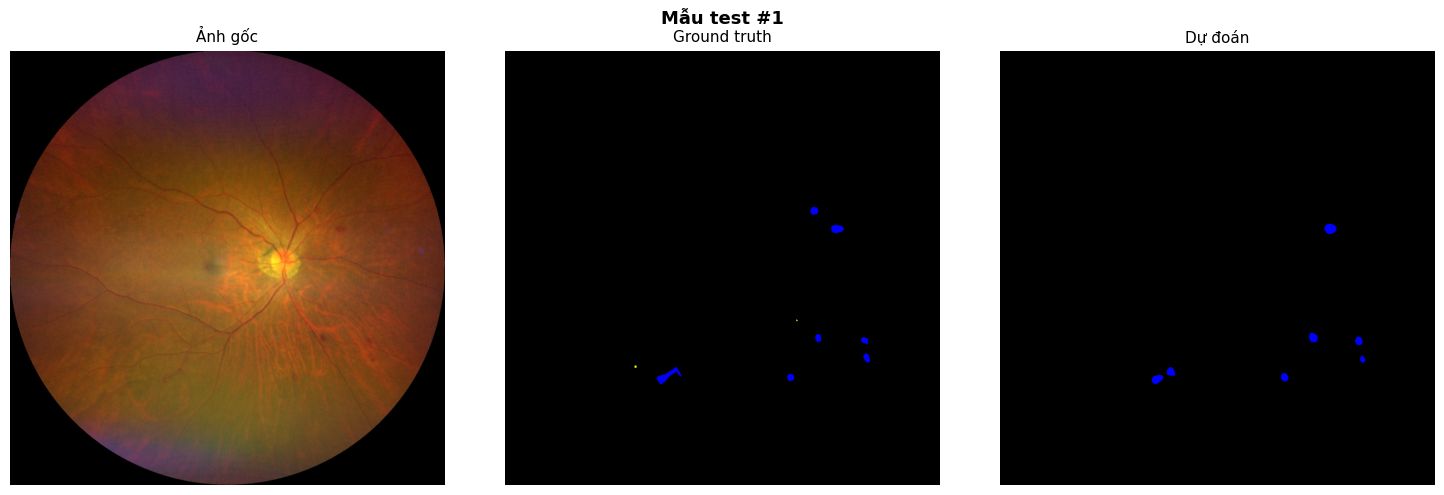

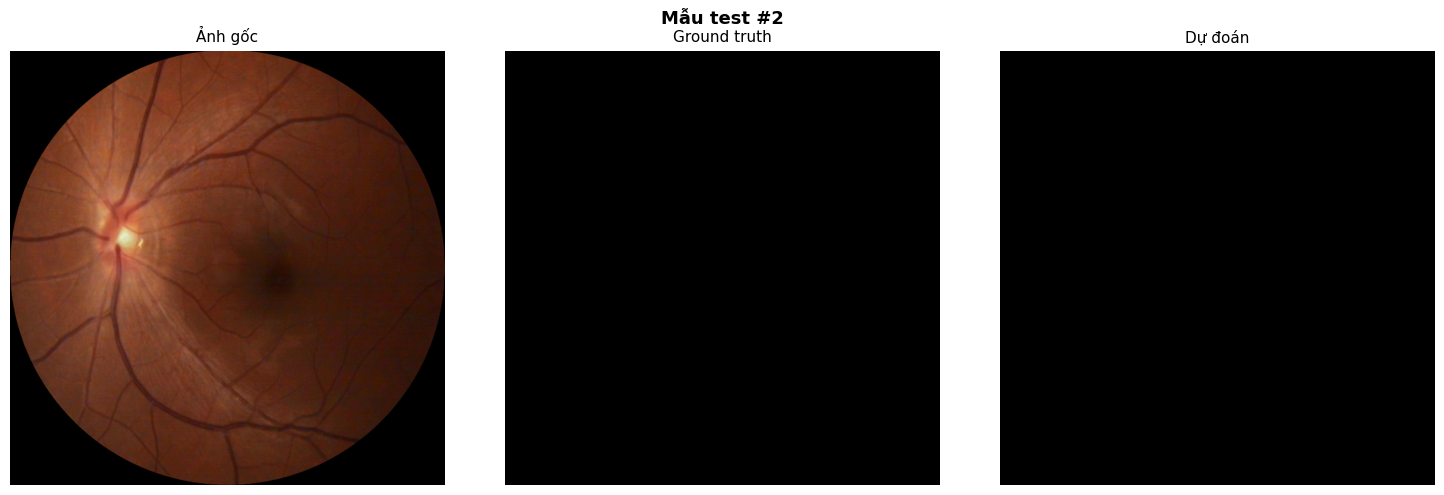

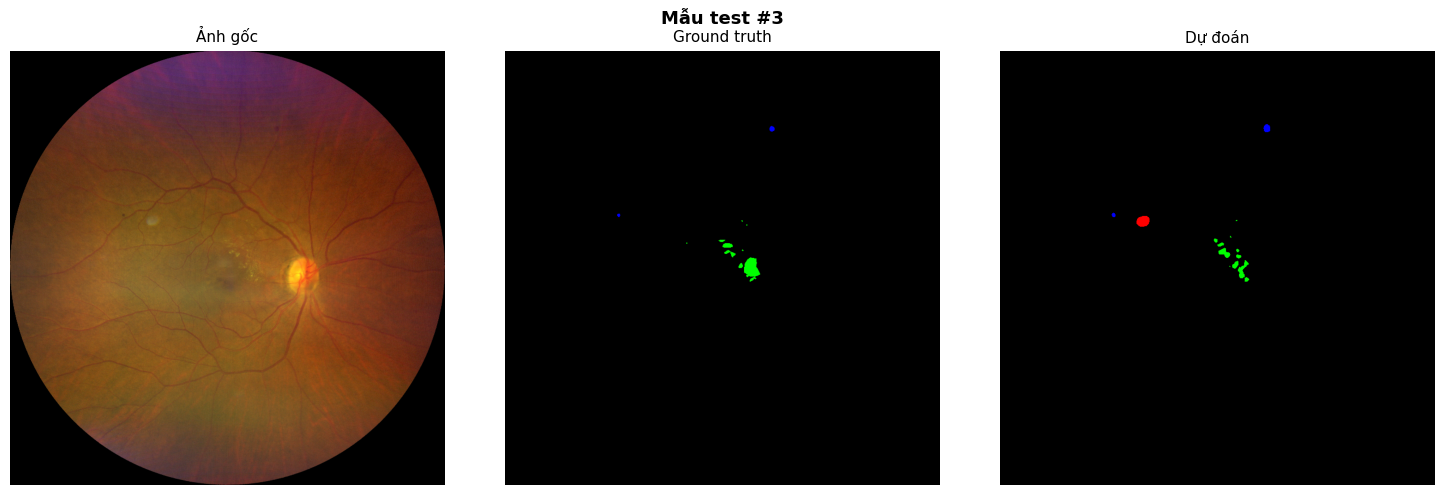

🎨 Chú thích màu: ⬛ Nền  🔴 EX  🟢 HE  🔵 MA  🟡 SE


In [12]:
COLORS    = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], np.uint8)
CLASS_LBL = ['BG', 'EX', 'HE', 'MA', 'SE']

def colorize(m):
    return COLORS[m]

model.eval()
shown = 0

with torch.no_grad():
    for x, y in test_dl:
        pred = model(x.to(device)).argmax(1)[0].cpu().numpy()
        img  = (x[0].permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN)).clip(0, 1)
        gt   = y[0].numpy()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Mẫu test #{shown+1}", fontsize=13, fontweight='bold')

        axes[0].imshow(img)
        axes[0].set_title('Ảnh gốc', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(colorize(gt))
        axes[1].set_title('Ground truth', fontsize=11)
        axes[1].axis('off')

        axes[2].imshow(colorize(pred))
        axes[2].set_title('Dự đoán', fontsize=11)
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()
        shown += 1
        if shown >= 3:
            break

print("🎨 Chú thích màu: ⬛ Nền  🔴 EX  🟢 HE  🔵 MA  🟡 SE")

---
## Cell 12 — 💾 Lưu model về Google Drive
> Copy `tjdr_unet_best.pth` từ Colab local (mất khi reset) → Google Drive (vĩnh viễn).

In [13]:
SAVE_PATH = '/content/drive/MyDrive/tjdr_unet_best.pth'
shutil.copy('tjdr_unet_best.pth', SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f"✅ Model đã lưu vào Drive")
print(f"   Đường dẫn : {SAVE_PATH}")
print(f"   Kích thước : {size_mb:.1f} MB")
print(f"   Best mDice : {best:.3f}")
print("\n📋 Ghi vào báo cáo (để tái lập):")
print(f"   - Seed split  = {SEED}  (tỉ lệ 70/15/15 theo ảnh)")
print(f"   - Kích thước  = {SIZE}×{SIZE}")
print(f"   - Encoder     = EfficientNet-B4 (pretrained ImageNet)")
print(f"   - Loss        = DiceLoss + FocalLoss(α=0.25, γ=2.0)")
print(f"   - Optimizer   = AdamW (lr=1e-4, wd=1e-4)")
print(f"   - GRAY2CLS    = {GRAY2CLS}")

✅ Model đã lưu vào Drive
   Đường dẫn : /content/drive/MyDrive/tjdr_unet_best.pth
   Kích thước : 81.7 MB
   Best mDice : 0.598

📋 Ghi vào báo cáo (để tái lập):
   - Seed split  = 42  (tỉ lệ 70/15/15 theo ảnh)
   - Kích thước  = 768×768
   - Encoder     = EfficientNet-B4 (pretrained ImageNet)
   - Loss        = DiceLoss + FocalLoss(α=0.25, γ=2.0)
   - Optimizer   = AdamW (lr=1e-4, wd=1e-4)
   - GRAY2CLS    = {0: 0, 15: 1, 38: 2, 75: 3, 113: 4}


---
## 📚 Tài liệu tham khảo

- Mao J., Ma X., Bi Y., Zhang R. (2023). *TJDR: A High-Quality Diabetic Retinopathy Pixel-Level Annotation Dataset.* arXiv:2312.15389.
- Mao J. et al. (2024). *A Comprehensive Federated Learning Framework for DR Grading and Lesion Segmentation.* IEEE Transactions on Big Data.
- Ronneberger O. et al. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI.
- Tan M., Le Q.V. (2019). *EfficientNet: Rethinking Model Scaling for CNNs.* ICML.